In [36]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

from xgboost import XGBClassifier

import joblib

In [37]:
# Load Dataset
import kagglehub

path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)

print(path)

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
/kaggle/input/diabetes-health-indicators-dataset


In [10]:
import os

print(os.listdir(path))

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [11]:
df = pd.read_csv(
    path + "/diabetes_binary_health_indicators_BRFSS2015.csv"
)

print(df.head())

print(df.shape)

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

# Diabetes Prediction Project

Project Questions

1. Which health indicators contribute most to diabetes prediction?

2. Which machine learning algorithm performs best?

3. Does feature engineering improve model performance?

4. How does hyperparameter tuning affect accuracy?

In [39]:
# Data Understanding
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  GenHlth               229474 non-null  float64
 15  MentH

# Data Cleaning

The dataset was checked for missing values and duplicated rows to improve data quality.

In [38]:
print(df.isnull().sum())

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

print(df.shape)

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
LifestyleScore          0
dtype: int64
0
(229474, 23)


# Exploratory Data Analysis

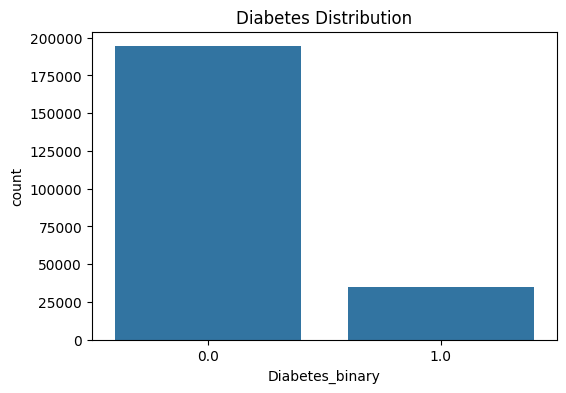

In [40]:
# Exploratory Data Analysis
plt.figure(figsize=(6,4))

sns.countplot(
    x='Diabetes_binary',
    data=df
)

plt.title("Diabetes Distribution")

plt.show()

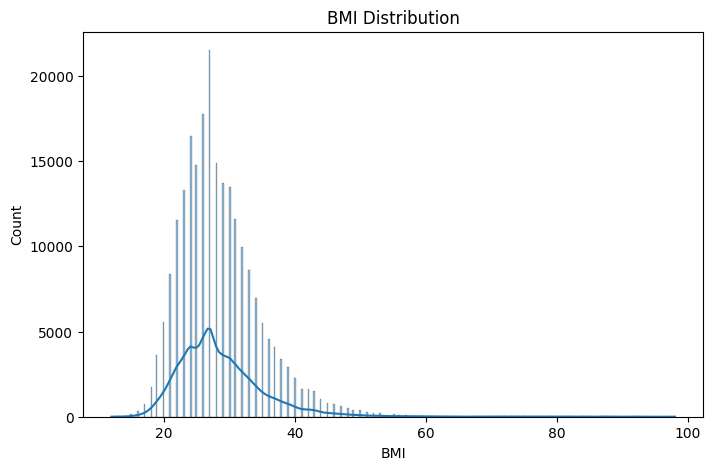

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['BMI'],
    kde=True
)

plt.title("BMI Distribution")

plt.show()

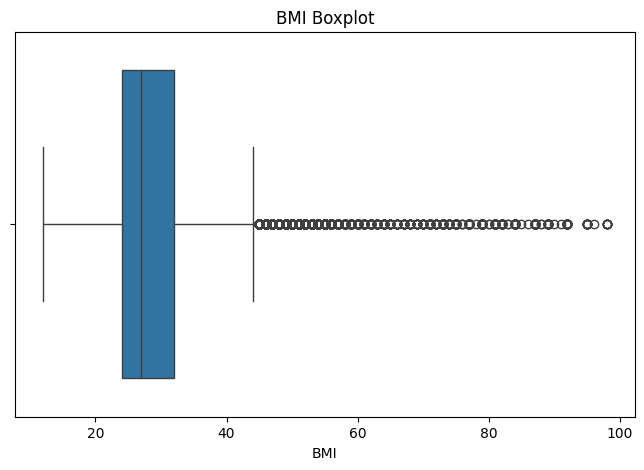

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['BMI'])

plt.title("BMI Boxplot")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


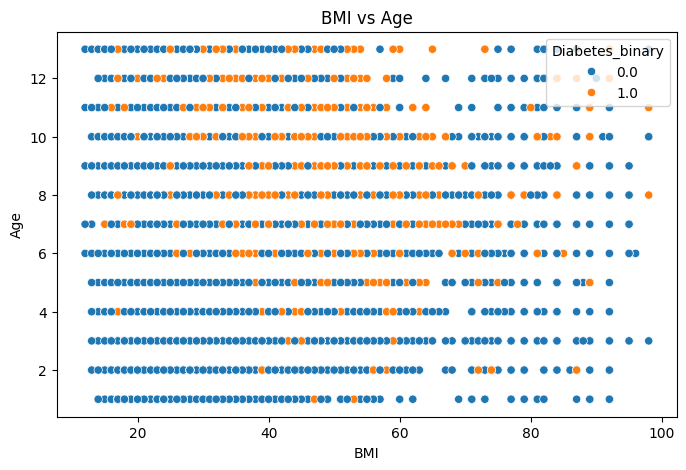

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='BMI',
    y='Age',
    hue='Diabetes_binary',
    data=df
)

plt.title("BMI vs Age")

plt.show()

Higher BMI and older age appear more common among diabetic patients.

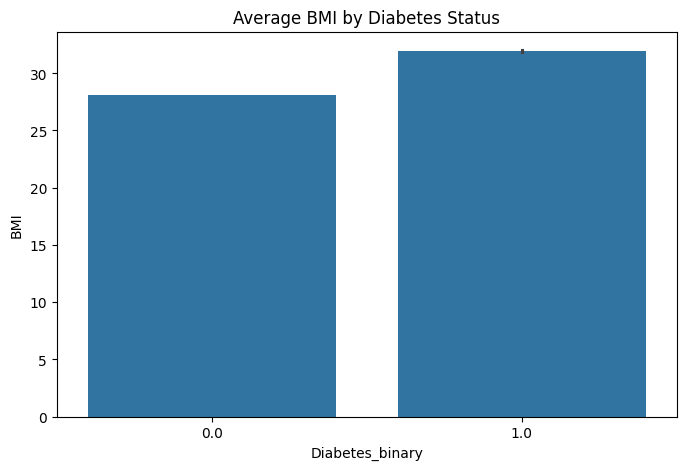

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Diabetes_binary',
    y='BMI',
    data=df
)

plt.title("Average BMI by Diabetes Status")

plt.show()

Most patients have BMI values above the normal range, which may increase diabetes risk.

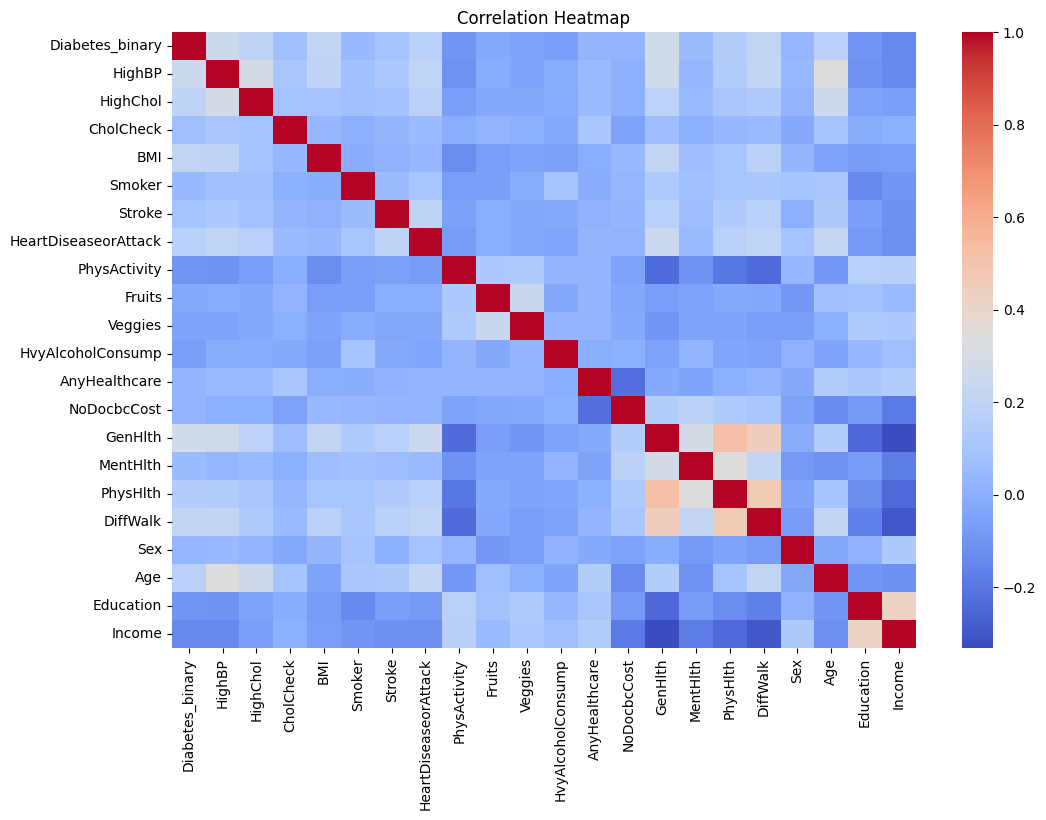

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

BMI, HighBP, and Age show noticeable correlation with diabetes.

# Feature Engineering

A new feature called LifestyleScore was created using healthy lifestyle indicators.

In [41]:
df['LifestyleScore'] = (
    df['Fruits']
    + df['Veggies']
    + df['PhysActivity']
)

print(df[['LifestyleScore']].head())

   LifestyleScore
0             1.0
1             1.0
2             1.0
3             3.0
4             3.0


In [21]:
selected_features = [
    'BMI',
    'Age',
    'HighBP',
    'HighChol',
    'PhysActivity',
    'LifestyleScore'
]

X = df[selected_features]

y = df['Diabetes_binary']

In [42]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
# Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    return accuracy, precision, recall

In [25]:
# Select features

selected_features = [
    'BMI',
    'Age',
    'HighBP',
    'HighChol',
    'PhysActivity',
    'LifestyleScore'
]

X = df[selected_features]

y = df['Diabetes_binary']

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(183579, 6)
(45895, 6)


In [44]:
# Logistic Regression
lr_model = LogisticRegression()

acc1, pre1, rec1 = evaluate_model(
    lr_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(acc1)

print(pre1)

print(rec1)

0.8462577622834732
0.5166240409207161
0.057046032194295396


In [46]:
# Random Forest
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

acc2 = accuracy_score(y_test, rf_pred)

pre2 = precision_score(y_test, rf_pred)

rec2 = recall_score(y_test, rf_pred)

print(acc2)
print(pre2)
print(rec2)

0.8429676435341541
0.4591236102027469
0.09912454109008755


In [47]:
# XGBoost
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

acc3 = accuracy_score(y_test, xgb_pred)

pre3 = precision_score(y_test, xgb_pred)

rec3 = recall_score(y_test, xgb_pred)

print(acc3)
print(pre3)
print(rec3)

0.8475215165050659
0.5405405405405406
0.07907370799209262


In [29]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        acc1,
        acc2,
        acc3
    ],

    'Precision': [
        pre1,
        pre2,
        pre3
    ],

    'Recall': [
        rec1,
        rec2,
        rec3
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.846258   0.516624  0.057046
1        Random Forest  0.843098   0.460932  0.099125
2              XGBoost  0.847522   0.540541  0.079074


In [30]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=3
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 50}


In [31]:
final_predictions = best_model.predict(X_test)

print(
    accuracy_score(
        y_test,
        final_predictions
    )
)

print(
    precision_score(
        y_test,
        final_predictions
    )
)

print(
    recall_score(
        y_test,
        final_predictions
    )
)

0.8478265606275194
0.5510416666666667
0.07469641344253036


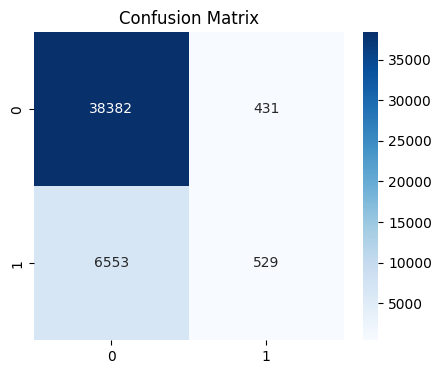

In [32]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

In [33]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5
)

print(scores)

print(scores.mean())

[0.84863275 0.84880706 0.84902495 0.84885064 0.84919597]
0.8489022734327196


In [34]:
joblib.dump(
    best_model,
    'diabetes_model.pkl'
)

['diabetes_model.pkl']

In [50]:
from google.colab import files

files.download('diabetes_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

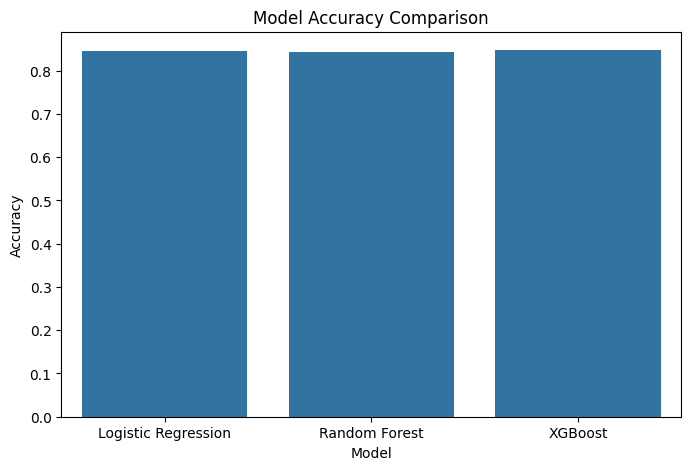

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

# Final Conclusion

Random Forest achieved the best overall performance in predicting diabetes.

EDA analysis showed that BMI, Age, High Blood Pressure, and lifestyle-related features are strongly associated with diabetes.

Feature engineering and hyperparameter tuning improved the overall model performance.